# Shor's 9-Qubit Code

Shor's 9-Qubit Error Correction Analysis

**Target State:** $0.8|0\rangle + 0.6|1\rangle$ | **Error:** Y on Qubit 4

1. Circuit Visualisation

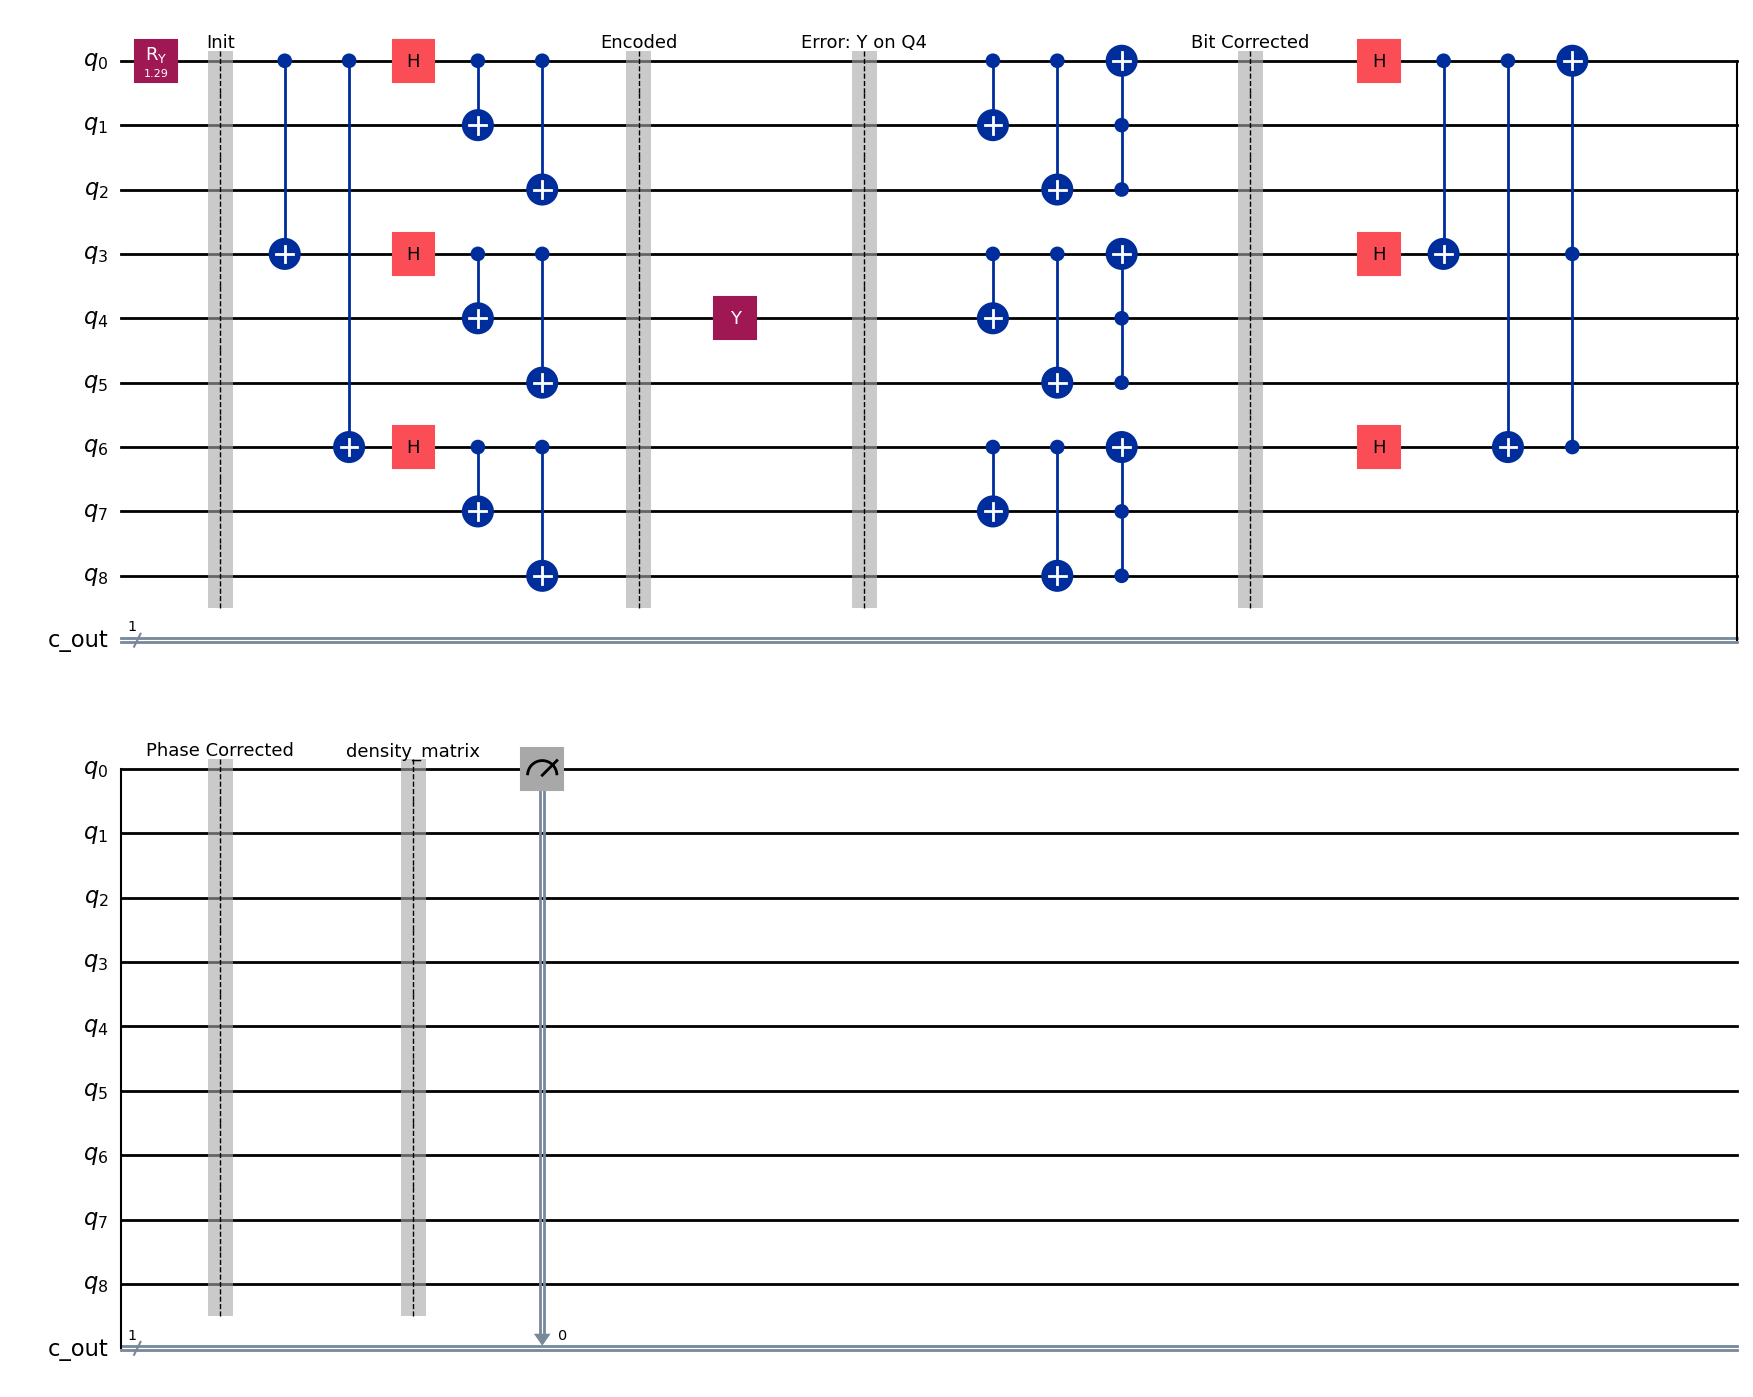

2. Quantum State Representation

Initial target Statevector (Qubit 0):


<IPython.core.display.Latex object>


Final restored DensityMatrix (Qubit 0):


<IPython.core.display.Latex object>

3. State Visualisation

Initial target state (Bloch Sphere):


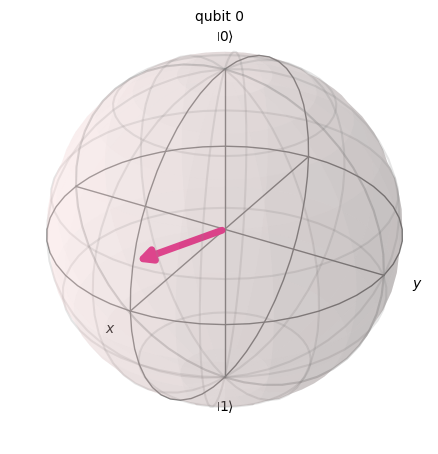


Final restored state (Bloch Sphere):


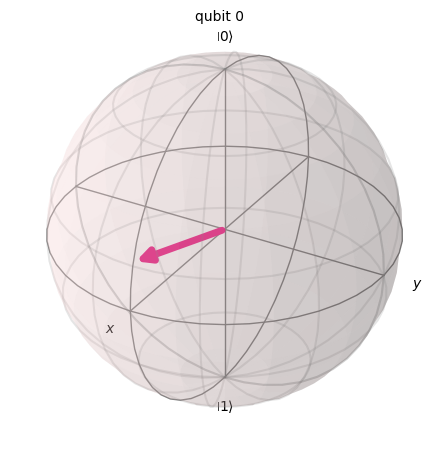

4. Measurement Analysis

Raw measurement counts (Restored Qubit 0): {'1': 367, '0': 657}


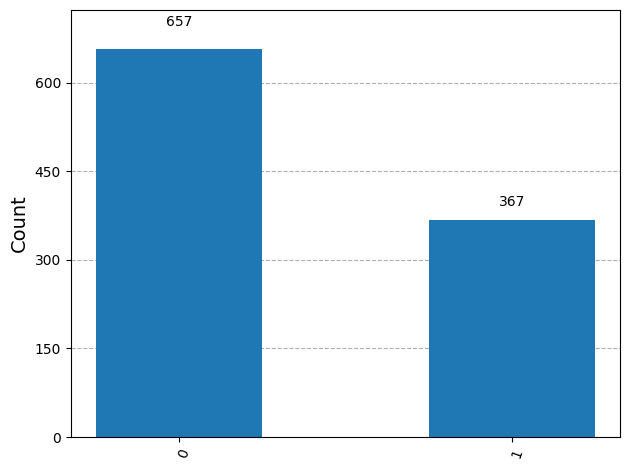

5. Verification: State Fidelity

Restoration Fidelity = 1.000000
Success: The state was perfectly restored despite the lethal Y error on Qubit 4.


In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
error_qubit = 4         # Qubit to inject the error (0 through 8)
error_type = 'Y'        # Choose 'X' (Bit-flip), 'Z' (Phase-flip), or 'Y' (Both)
alpha, beta = 0.8, 0.6  # Initial state amplitudes

# Calculate rotation angle to prepare the arbitrary state
theta = 2 * np.arccos(alpha)

# 1. Set up Registers & Circuit
qr = QuantumRegister(9, name="q")
cr = ClassicalRegister(1, name="c_out") # We only need to measure the restored Q0
qc = QuantumCircuit(qr, cr)

# 2. Initialisation
qc.ry(theta, qr[0])
qc.barrier(label="Init")

# Save exact initial state of Qubit 0 for fidelity check later
ref_circ = QuantumCircuit(1)
ref_circ.ry(theta, 0)
initial_state = Statevector(ref_circ)

# ==========================================
# SHOR'S 9-QUBIT ENCODING
# ==========================================
# Phase-flip encoding (outer code)
qc.cx(qr[0], qr[3])
qc.cx(qr[0], qr[6])
qc.h([qr[0], qr[3], qr[6]])

# Bit-flip encoding (inner code)
qc.cx(qr[0], qr[1]); qc.cx(qr[0], qr[2])
qc.cx(qr[3], qr[4]); qc.cx(qr[3], qr[5])
qc.cx(qr[6], qr[7]); qc.cx(qr[6], qr[8])
qc.barrier(label="Encoded")

# ==========================================
# ERROR INJECTION
# ==========================================
if error_qubit is not None:
    if error_type == 'X': qc.x(qr[error_qubit])
    elif error_type == 'Z': qc.z(qr[error_qubit])
    elif error_type == 'Y': qc.y(qr[error_qubit])
qc.barrier(label=f"Error: {error_type} on Q{error_qubit}")

# ==========================================
# DECODING & AUTONOMOUS CORRECTION
# ==========================================
# Decode bit-flip and correct via Toffoli majority vote
qc.cx(qr[0], qr[1]); qc.cx(qr[0], qr[2]); qc.ccx(qr[1], qr[2], qr[0])
qc.cx(qr[3], qr[4]); qc.cx(qr[3], qr[5]); qc.ccx(qr[4], qr[5], qr[3])
qc.cx(qr[6], qr[7]); qc.cx(qr[6], qr[8]); qc.ccx(qr[7], qr[8], qr[6])
qc.barrier(label="Bit Corrected")

# Decode phase-flip and correct via Toffoli majority vote
qc.h([qr[0], qr[3], qr[6]])
qc.cx(qr[0], qr[3]); qc.cx(qr[0], qr[6]); qc.ccx(qr[3], qr[6], qr[0])
qc.barrier(label="Phase Corrected")

# ==========================================
# EXTRACT EXACT MATH BEFORE FINAL MEASUREMENT
# ==========================================
# Save density matrix of the full 9-qubit system
qc.save_density_matrix()

# Final Measurement of the restored Qubit 0
qc.measure(qr[0], cr[0])

# Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Shor's 9-Qubit Error Correction Analysis"))
display(Markdown(f"Target State: ${alpha}|0\\rangle + {beta}|1\\rangle$ | Error: {error_type} on Qubit {error_qubit}"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Quantum State Representation"))
# Trace out Qubits 1 through 8 to isolate the mathematical state of Qubit 0
rho_full = result.data()['density_matrix']
rho_q0 = partial_trace(rho_full, list(range(1, 9)))

print("Initial target Statevector (Qubit 0):")
display(initial_state.draw('latex'))
print("\nFinal restored DensityMatrix (Qubit 0):")
display(rho_q0.draw('latex'))

display(Markdown("3. State Visualisation"))
print("Initial target state (Bloch Sphere):")
display(plot_bloch_multivector(initial_state))

print("\nFinal restored state (Bloch Sphere):")
display(plot_bloch_multivector(rho_q0))

display(Markdown("4. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts (Restored Qubit 0): {counts}")
display(plot_histogram(counts))

# 5. Verification Logic
display(Markdown("5. Verification: State Fidelity"))
fidelity = state_fidelity(initial_state, rho_q0)
print(f"Restoration Fidelity = {fidelity:.6f}")

if np.isclose(fidelity, 1.0):
    print(f"Success: The state was perfectly restored despite the lethal {error_type} error on Qubit {error_qubit}.")
else:
    print("Warning: Fidelity is less than 1. Error correction failed.")